<a href="https://colab.research.google.com/github/Jxhyxxk/Python_jxhyxxk/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_%EA%B8%B0%EB%A7%90%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **개념 정리**

용어

In [ ]:
'''

1. Classification(분류)
  - 입력 이미지가 어떤 클래스(구분하고 싶은 대상의 종류)에 속하는지 예측하는 작업

2. Object Detection(객체 탐지)
  - 입력 이미지에서 어떤 객체(찾아야할 대상)가 있는지 찾아내고, classification(찾은 객체가 무엇인지)으로 가서 무엇인지 인식하는 것

3. Segmentiation(분할)
  - 이미지를 Pixel 단위로 분류하여 각 Pixel이 어떤 의미 있는 영역에 속하는지 예측하는 것

4. Convolution layer
  - 입력 이미지에서 특징을 추출하는 핵심 층
    커널을 이동시키며 입력 이미지와의 합성곱을 수행하여 특징맵(Feature map)을 생성

5. Padding
  - 입력 이미지의 가장자리 부분이 Convolution 연산에서 손실되는 것을 방지하기 위해 사용
    이미지 크기를 일정하게 유지하여 정보 손실을 줄인다.
  - 가장자리에 0 또는 지정한 값을 덧붙여 이미지의 크기를 유지시킴

6. Stride
  - Convolution 연산할 때 커널을 이동시키는 간격

7. Pooling layer
  - Feature map 크기를 줄여 매개변수 수를 감소시키고 Overfitting 방지

8. Channel (U-net)
  - 입력 단계: 색상 정보 - 흑백은 1채널, RGB는 3채널
  - 첫 번째 Conv: 기초적인 패턴 - 수평선, 수직선, 경계, 밝기 변화
  - 중간 Conv: 조합된 모양들 - 점, 곡선, 네모, 윤곽선, 질감
  - Bottleneck: 추상적인 의미 - 이건 폐다, 여기 뭐가있다
  - 업샘플링 후: 위치정보 + 의미 조합 - 어디에 뭐가있다.
  - 출력층: 채널 수 = 클래스(각 픽셀이 어떤 종류에 속하는지) 수

9. IoU (Intersection over Union)
  - (겹친 영역)/(합쳐진 전체영역)
  - 두 마스크(예측 vs 정답)가 얼마나 잘 겹쳤는지

10. 2X2 transposed convolution(전치 합성곱)
  - U-Net의 Upsampling 과정의 연산
  - 크기를 2배로 확대해줌
  - 중간에 0이나 Padding을 넣어 공간을 확보

11. unet의 마스크 영상
  - 입력 이미지에서 각 픽셀이 어떤 클래스에 속하는지를 나타낸 정답(label) 이미지.

'''

In [ ]:
'''

출력 Feature map의 크기 : 출력 크기 = (입력 크기 - 커널크기) / Stride + 1

파라미터 개수 : 커널 크기 X 커널 개수 + 2(바이어스) + 1

'''

CNN(Convolution Neural Network)

In [ ]:
'''
 ● CNN(합성곱 신경망) 은 이미지 분류, 객체 탐지, 영상 인식 등에 사용되는 모델
   - 기존에는 Flatten하여서 처리하였지만 CNN은 이미지의 공간적 구조를 그대로 유지하면서 학습함.

 ● Convolution Layer
   - 3X3, 5X5등의 커널을 이용하게됨.
   - 이미지는 커널을 통과하면서 크기가 작아지고 커널을 통과한 이미지는 Feature Map을 형성함.
   - 이미지의 크기는 padding을 이용하면 이미지의 크기는 변화하지 않음

 ● Activation Fuction(활성화 함수)
  - ReLU 함수를 사용함
    0보다 작으면 0, 크면 그대로 출력  ->  음수를 0으로 바꿈

 ● Pooling Layer
  - Convolution의 통과 결과인 Feature Map의 크기를 줄이고 중요한 정보만 남김
  - MaxPooling2D(pool_size=(2,2)) -> 이 코드를 통해서 Pooling 시킴


 ● Flatten Layer
  - 이전의 데이터를 1차원으로 만들어줌
  - 출력 단계의 계산은 1차원 이어야 하기 때문에

 ● Dense Layer
  - CNN이 뽑아낸 특징을 바탕으로 분류를 수행

U-Net

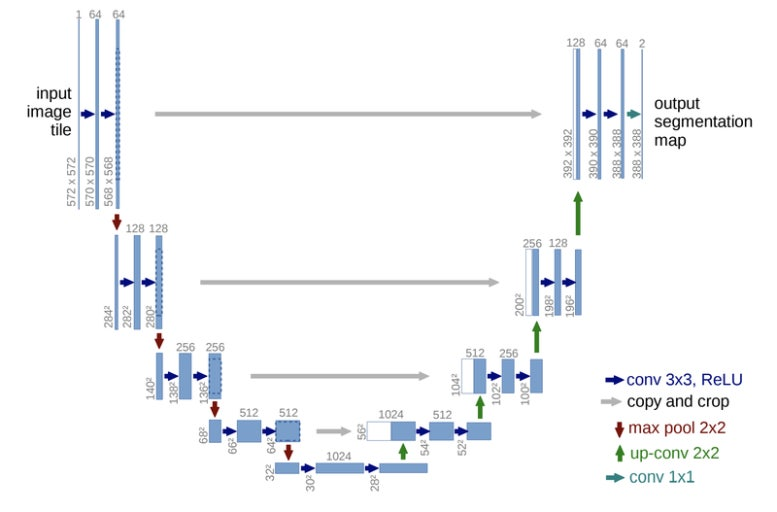

In [ ]:
'''

※ 왼쪽은 축소(인코더), 오른쪽은 확장(디코더)  -> 입력 이미지에서 세부 위치와 의미를 파악

● 왼쪽 인코더
  - conv 3X3, ReLU : 3X3 필터, Padding 없이 적용, 비선형성 추가
  - max pool 2X2 : 크기를 절반으로 줄임
  - 인코더 에서는 max pool을 통해 크기를 절반씩 줄이게 됨
  - 이미지 크기를 줄이면서 더 깊은 특징을 추출하고 채널 수가 많아진다 (더 다양한 의미 학습)  -> Conv와 MaxPooling을 반복하면 채널의 수는 2배 증가함

● 가운데 Bottleneck
  - 특징만 남고 위치 정보는 거의 없다 (압축된 상태)

● 오른쪽 디코더
  - up-conv 2X2: 해상도를 높임 (upsampling)
  - conv 3X3, ReLU: conv를 통해서 의미 보완
  - copy and crop: Feature map을 복사해서 붙임  -> 정확한 Segmentation이 가능해짐
  - 크기가 증가하고 채널 수가 감소한다.

● 출력층
  - conv 1X1: 픽셀당 클래스 수로 채널 축소
  - 출력층 막대기 위에있는 2는 클래스를 나타냄 -> 분류하는 클래스에 따라서 숫자는 바뀜
  - Binary: 각 픽셀이 객체인지 아닌지 / 활성화 함수: Sigmoid
  - Multi-class: 각 픽셀이 어떤 클래스인지 / 활성화 함수: Softmax

'''

Dice coefficient

In [ ]:
'''

※수식
           2×∣A∩B∣
Dice(A,B)= -----------
              ∣A∣+∣B∣

* A: 정답 마스크(Ground truth), B: 모델이 예측한 마스크(Prediction), A∩B: 두 마스크가 겹치는 부분


개념: 두 집합(또는 두 이미지)이 얼마나 겹치는지를 측정하는 지표
범위: 1.0(완벽히 일치), 0.0(전혀 겹치지 X), 0.5(절반 정도만 겹침)

- 두 마스크의 모양이 잘 겹칠수록 Dice 값은 증가한다.  -> 1에 가까울수록 좋음
​
'''

CNN 코드 해석

In [ ]:
import os
import numpy as np
import cv2
from google.colab.patches import cv2_imshow


# '/content/drive/MyDrive/number_3class' 폴더 안에 영상들을 data_path에 저장
data_path = '/content/drive/MyDrive/number_3class'

image_rows = 28 # 입력영상 높이
image_cols = 28 # 입력영상 너비  -> 밑에서 사용

# 폴더 밑에 있는 영상 파일 이름을 리스트로 가져와서 image_file_names에 저장
image_file_names = os.listdir(data_path)

# train 폴더 밑의 전체 영상 갯수
total = len(image_file_names)

# 여러개 영상들을 다루기 위한 영상 배열, mnist 와 형식 같음

imgs = np.ndarray((total, image_rows, image_cols), dtype=np.uint8)
# -> 이미지에 대한 정보들을 uint8형식으로 imgs에 저장할 3차원 배열 생성

for image_name in image_file_names:
# -> 폴더에 있는 사진을 하나씩 처리하겠다

file_name = os.path.join(class_data_path, image_name)
# -> 실제 이미지가 저장된 전체 경로(파일 위치)를 만든다

img = cv2.imread(file_name,cv2.IMREAD_GRAYSCALE)
# -> 사진을 OpenCV를 통해서 흑백(1채널)로 불러옴

img = cv2.resize(img, (image_cols, image_rows))
# -> 불러온 사진을 CNN에 적용하기 위한 크기로 resize

imgs[i] = img
# -> 전처리한 이미지를 imgs 배열에 한 칸씩 저장

i = i + 1
# -> 이미지 한 장이 imgs배열에 저장되었기 때문에 다음 사진을 위해 i의 값을 한 개 늘림

np.save('images.npy', imgs) # numpy 형식으로 파일 저장
read_images = np.load('images.npy') # 저장된 numpy 파일 읽기
print ('저장된 npy 파일 shape = ', read_images.shape)

In [ ]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow

# 설정
img_size = 28  # 이미지 크기
ch = 1         # 채널 수  (흑백이면 1, 컬러면 3)

# 데이터 준비

# 이미지를 학습과 테스트용으로 인덱싱, 이 코드에서 사용하는 사진은 총 9장
train_imgs = imgs[:6] # 6장을 train으로 사용
test_imgs = imgs[6:]  # 뒤에 나머지 3장을 test로 사용

train_labels = np.array([1, 1, 1, 0, 2, 2]) # train 사진의 label 설정
test_labels = np.array([0, 2, 0])           # test 사진의 label 설정

# 데이터 전처리 밑 정규화
train_imgs = train_imgs.reshape(-1, img_size, img_size, ch)[..., ::-1].astype('float32') / 255
test_imgs = test_imgs.reshape(-1, img_size, img_size, ch)[..., ::-1].astype('float32') / 255
# .reshape(-1, img_size, img_size, ch) -> -1은 자동으로 맞춘다는 뜻이고 이미지의 -1을 넣기 싫으면 이미지의 개수와 같은 값을 넣으면 됨 이 코드에서는 6장을 train으로 사용하기 때문에 6이 들어가면됨
#                                         즉, 이 코드는 이미지의 형태에 채널을 추가하는 reshape 코드임

# .astype('float32') / 255 -> 흑백 사진이기 때문에 픽셀 값의 범위는 0~255인데 이 값을 계산에 용이하게 바꾸기 위해 255로 나누어 픽셀 값을 0~1로 정규화 하는 코드

train_labels = to_categorical(train_labels, 3)
test_labels = to_categorical(test_labels, 3)
#정수형 label을 one-hot encoding 시키는 코드  -> 마지막에 Softmax를 위해 바꿔줌

# 예시 이미지 출력
sample = cv2.resize(train_imgs[0], (256, 256), interpolation=cv2.INTER_NEAREST)
cv2_imshow(sample)

# 모델 구성
model = Sequential([
    Conv2D(6, (3, 3), activation='relu', input_shape=(img_size, img_size, ch)),   # 특징 추출용 3X3 필터 6개
    MaxPooling2D(pool_size=(2, 2)),                                               # 2X2 Pooling을 이용하여 크기를 절반으로 줄임 / Downsampling
    Conv2D(16, (3, 3), activation='relu'),                                        # 3X3 필터 16개, 더 깊은 특징을 추출함
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),                                                                # Overfitting 방지를 위한 Dropout
    Flatten(),                                                                    # 2D 형태를 1D 형태로 펼침
    Dense(128, activation='relu'),                                                # 뉴런 128개를 이용해서 중간 판단
    Dropout(0.5),                                                                 # 뉴런 절반을 날림
    Dense(3, activation='softmax')                                                # Softmax하여 3개의 클래스 확률을 출력
])

# Output shape 확인 하기 (아래 표로 확인)
# Input shape = (28, 28, 1)
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼─────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 6)      │             0 │
├─────────────────────────────────┼─────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 16)     │           880 │
├─────────────────────────────────┼─────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼─────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼─────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼─────┤
│ dense_2 (Dense)                 │ (None, 128)            │        51,328 │
├─────────────────────────────────┼─────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼─────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴─────┘

# 컴파일 및 요약
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# 학습
print('Training...')
history = model.fit(train_imgs, train_labels, batch_size=512, epochs=50, validation_split=0.1)

# 평가
score = model.evaluate(test_imgs, test_labels, verbose=0)
print("Test accuracy:", score[1])

# 손실 시각화
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, 'b-', label='Training loss')
plt.plot(epochs, val_loss_values, 'g-', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 테스트 이미지 출력
selected_indices = [1, 1, 1]
selected_imgs = imgs[selected_indices]
selected_labels = [train_labels[i] for i in selected_indices]

plt.figure(figsize=(8, 3))
for i in range(len(selected_indices)):
    plt.subplot(1, len(selected_indices), i + 1)
    plt.imshow(selected_imgs[i], cmap='gray', interpolation='nearest', vmin=0, vmax=255)
    plt.title(f"{selected_labels[i]}", color='red', fontsize=16)
    plt.axis('off')
plt.tight_layout()
plt.show()


U-Net

In [ ]:
# 영상 전처리 코드
import os
import numpy as np
import cv2

# 각 폴더의 영상과 해당되는 마스크 영상의 이름은 동일해야 한다.
img_dir = 'drive/MyDrive/data/raw-cmr-small/'
data_dir = 'drive/MyDrive/data/raw-cmr-small/'

#폴더에 있는 이미지를 변환하기 위한 선언
image_rows = 256  # 저장할 영상 높이
image_cols = 256  # 저장할 영상 너비

def read_imgs(img_path, mask_path):
    images = os.listdir(img_path)  # 입력 이미지 파일 이름 리스트
    total = len(images)  # 총 이미지 수

    mask_images = os.listdir(mask_path)  # 마스크 이미지 파일 이름 리스트
    mask_total = len(mask_images)  # 총 마스크 수

    imgs = np.zeros((total, image_rows, image_cols), dtype=np.uint8)
    mask_imgs = np.zeros((mask_total, image_rows, image_cols), dtype=np.uint8) # 영상 데이터를 담을 빈 Numpy 배열 생성

    # 이미지와 마스크의 갯수가 다르면 오류 메시지 출력 및 저장하지 않고 빈 배열을 반환시킴
    if total != mask_total:
        print('Error in number of images and mask_images')
        return imgs, mask_imgs

    i = 0
    print('Making numpy array from images...')

    for image_name in images:
        print(i)
        # 영상 불러오기 및 크기 조정
        img = cv2.imread(os.path.join(img_path, image_name), cv2.IMREAD_GRAYSCALE) # 이미지를 흑백으로 불러오기
        tmp = cv2.resize(img, (image_cols, image_rows), interpolation=cv2.INTER_CUBIC) # 이미지를 256X256 크기로 리사이즈
        imgs[i] = tmp  # 리사이즈된 이미즈를 배열에 저장

        # 마스크 영상도 동일하게 처리
        img = cv2.imread(os.path.join(mask_path, image_name), cv2.IMREAD_GRAYSCALE)
        tmp = cv2.resize(img, (image_cols, image_rows), interpolation=cv2.INTER_CUBIC)
        mask_imgs[i] = tmp

        i += 1

    print(str(total) + '  Loading done.')
    return imgs, mask_imgs

def vis_img_mask(imgs, mask_imgs, wn):
    size = int(imgs.shape[0] / 5)
    w = imgs.shape[2]
    h = imgs.shape[1]
    t_img = np.zeros((2 * h, 6 * w), np.uint8)

    for i in range(5):
        t_img[0:h, i * w:i * w + w] = imgs[i * size]
        t_img[h:2 * h, i * w:i * w + w] = mask_imgs[i * size]

    t_img[0:h, 5 * w:6 * w] = imgs[-1]
    t_img[h:2 * h, 5 * w:6 * w] = mask_imgs[-1]

    from google.colab.patches import cv2_imshow
    cv2_imshow(t_img)

# train용 이미지와 마스크를 numpy 형태로 저장
def create_train_data():
    imgs, mask_imgs = read_imgs(img_dir + 'train', img_dir + 'train_mask')
    np.save(data_dir + 'imgs_train.npy', imgs)
    np.save(data_dir + 'imgs_mask_train.npy', mask_imgs)
    vis_img_mask(imgs, mask_imgs, 'train')

# test용 이미지와 마스크를 numpy 형태로 저장
def create_test_data():
    imgs, mask_imgs = read_imgs(img_dir + 'test', img_dir + 'test_mask')
    np.save(data_dir + 'imgs_test.npy', imgs)
    np.save(data_dir + 'imgs_mask_test.npy', mask_imgs)
    vis_img_mask(imgs, mask_imgs, 'test')

if __name__ == '__main__':
    create_train_data()
    create_test_data()


In [ ]:
# npy 영상을 읽어 (img_rows, img_cols) 크기로 영상을 resize 하고 위 keras data 형식으로
# 누적해서 만들어줄함.
# 영상을 255로 나누어 level을 정규화 하고 u-net에 입력하여 train 하고 test 함.

import os
import cv2
import numpy as np
from keras.models import Model
from keras.layers import Input, concatenate, Dropout, Conv2D, MaxPooling2D, Conv2DTranspose
from keras.optimizers import Adam
from keras import backend as K
from google.colab.patches import cv2_imshow
import tensorflow as tf
import matplotlib.pyplot as plt

img_rows = 256
img_cols = 256
ch = 1
smooth = 1.
data_path = 'drive/MyDrive/raw-cmr-small/'

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

# Numpy 형태의 train 이미지, 마스크 불러오기
def load_train_data():
    imgs_train = np.load(data_path + 'imgs_train.npy')
    imgs_mask_train = np.load(data_path + 'imgs_mask_train.npy')
    return imgs_train, imgs_mask_train

# Numpy 형태의 test 이미지, 마스크 불러오기
def load_test_data():
    imgs_test = np.load(data_path + 'imgs_test.npy')
    imgs_mask_test = np.load(data_path + 'imgs_mask_test.npy')
    return imgs_test, imgs_mask_test

# Dice Coefficient 정의
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Dice Coefficient 손실함수 정의
def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)


# U-Net 모델 구
def get_unet2():
    inputs = Input((img_rows, img_cols, ch))

# Encoder
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

# Bottleneck
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

# Decoder
    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    model = Model(inputs=[inputs], outputs=[conv10])
    model.compile(optimizer=Adam(learning_rate=1e-5), loss=dice_coef_loss, metrics=[dice_coef])
    return model

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                             ┃ Output Shape           ┃ Param #     ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Input (InputLayer)                       ┃ (None, 256, 256, 1)    ┃ 0           ┃
┃ conv1_1 (Conv2D)                         ┃ (None, 256, 256, 32)   ┃ 320         ┃
┃ conv1_2 (Conv2D)                         ┃ (None, 256, 256, 32)   ┃ 9,248       ┃
┃ pool1 (MaxPooling2D)                     ┃ (None, 128, 128, 32)   ┃ 0           ┃
┃ conv2_1 (Conv2D)                         ┃ (None, 128, 128, 64)   ┃ 18,496      ┃
┃ conv2_2 (Conv2D)                         ┃ (None, 128, 128, 64)   ┃ 36,928      ┃
┃ pool2 (MaxPooling2D)                     ┃ (None, 64, 64, 64)     ┃ 0           ┃
┃ conv3_1 (Conv2D)                         ┃ (None, 64, 64, 128)    ┃ 73,856      ┃
┃ conv3_2 (Conv2D)                         ┃ (None, 64, 64, 128)    ┃ 147,584     ┃
┃ pool3 (MaxPooling2D)                     ┃ (None, 32, 32, 128)    ┃ 0           ┃
┃ conv4_1 (Conv2D)                         ┃ (None, 32, 32, 256)    ┃ 295,168     ┃
┃ conv4_2 (Conv2D)                         ┃ (None, 32, 32, 256)    ┃ 590,080     ┃
┃ pool4 (MaxPooling2D)                     ┃ (None, 16, 16, 256)    ┃ 0           ┃
┃ conv5_1 (Conv2D)                         ┃ (None, 16, 16, 512)    ┃ 1,180,160   ┃
┃ conv5_2 (Conv2D)                         ┃ (None, 16, 16, 512)    ┃ 2,359,808   ┃
┃ up6 (Conv2DTranspose + concat)           ┃ (None, 32, 32, 512)    ┃ -           ┃
┃ conv6_1, conv6_2 (Conv2D)                ┃ (None, 32, 32, 256)    ┃ ~885K       ┃
┃ up7 (Conv2DTranspose + concat)           ┃ (None, 64, 64, 256)    ┃ -           ┃
┃ conv7_1, conv7_2 (Conv2D)                ┃ (None, 64, 64, 128)    ┃ ~295K       ┃
┃ up8 (Conv2DTranspose + concat)           ┃ (None, 128, 128, 128)  ┃ -           ┃
┃ conv8_1, conv8_2 (Conv2D)                ┃ (None, 128, 128, 64)   ┃ ~73K        ┃
┃ up9 (Conv2DTranspose + concat)           ┃ (None, 256, 256, 64)   ┃ -           ┃
┃ conv9_1, conv9_2 (Conv2D)                ┃ (None, 256, 256, 32)   ┃ ~18K        ┃
┃ conv10 (Conv2D)                          ┃ (None, 256, 256, 1)    ┃ 33          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛



# 입력 이미지들을 (256, 256, 1) 형태로 resize 하고 새로운 배열에 저장
def preprocess(imgs):
    imgs_p = np.ndarray((imgs.shape[0], img_rows, img_cols, ch), dtype=np.uint8)
    for i in range(imgs.shape[0]):
        tmp1 = cv2.resize(imgs[i], (img_cols, img_rows), interpolation=cv2.INTER_CUBIC)
        imgs_p[i, :, :, 0] = tmp1
    return imgs_p

# 마스크를 (256, 256, 1) 형태로 resize 하고 새로운 배열에 저장
def preprocess_mask(imgs):
    imgs_p = np.ndarray((imgs.shape[0], img_rows, img_cols, 1), dtype=np.uint8)
    for i in range(imgs.shape[0]):
        tmp = cv2.resize(imgs[i], (img_cols, img_rows), interpolation=cv2.INTER_CUBIC)
        imgs_p[i, :, :, 0] = tmp
    return imgs_p

# 학습 및 예측 과정 실행하는 함수
def train_and_predict():
    print('Loading and preprocessing train data...')
    imgs_train, imgs_mask_train = load_train_data()  # 저장된 Numpy 형식의 데이터를 불러옴
    imgs_train = preprocess(imgs_train)              # 위에서 선언한 preprocess를 통해서 이미지, 마스크 resize
    imgs_mask_train = preprocess_mask(imgs_mask_train)

    cv2_imshow(imgs_train[0, :, :, 0])
    cv2_imshow(imgs_mask_train[0, :, :, 0])     # 첫 번째 학습 이미지와 마스크 시각화

    imgs_train = imgs_train.astype('float32') / 255
    imgs_mask_train = imgs_mask_train.astype('float32') / 255  # 픽셀 값 정규화

    np.random.seed(1234)
    valid_size = int(0.2 * imgs_train.shape[0])   # 전체 학습 중 20%를 Validation으로 사용
    random_index = np.random.choice(imgs_train.shape[0], imgs_train.shape[0], replace=False)
    valid_imgs_train = imgs_train[random_index[:valid_size]] # 앞부분 20% 검증용
    valid_imgs_mask_train = imgs_mask_train[random_index[:valid_size]]

    imgs_train = imgs_train[random_index[valid_size:]]  # 나머지 80% 실제 학습용
    imgs_mask_train = imgs_mask_train[random_index[valid_size:]]

    print('Creating and compiling model...')
    model = get_unet2() # 모델을 U-Net으로 정의
    model.summary()

    print('Fitting model...')
    epoch = 300
    history = model.fit(
        imgs_train, imgs_mask_train,
        batch_size=2,
        epochs=epoch,
        verbose=1,
        shuffle=True,
        validation_data=(valid_imgs_train, valid_imgs_mask_train)
    )

    loss_values = history.history['loss']
    val_loss_values = history.history['val_loss']
    epochs_range = range(1, epoch + 1)

    plt.plot(epochs_range, loss_values, 'b+', label='Training loss')
    plt.plot(epochs_range, val_loss_values, 'g+', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print('Loading and preprocessing test data...')
    imgs_test, imgs_mask_test = load_test_data()
    imgs_test = preprocess(imgs_test)
    imgs_mask_test = preprocess_mask(imgs_mask_test)
    imgs_test = imgs_test.astype('float32') / 255
    imgs_mask_test = imgs_mask_test.astype('float32') / 255

    print('Predicting masks on test data...')
    imgs_test_pred = model.predict(imgs_test, batch_size=2, verbose=1)
    np.save(data_path + 'imgs_test_pred.npy', imgs_test_pred)

    dice_coeff = 0.0     # Dice 계수 변수 초기화
    for i in range(imgs_test.shape[0]):
        y_true_f = imgs_mask_test[i, :, :, 0]
        y_pred_f = imgs_test_pred[i, :, :, 0]
        intersection = np.sum(y_true_f * y_pred_f)
        dice = (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)
        dice_coeff += dice
        print(i, dice)   # -> 테스트 이미지마다 예측된 마스크와 실제 마스크를 비교하여 Dice 계수 계산

    dice_coeff /= imgs_test.shape[0]   # 전체 테스트 셋의 평균 Dice 계수 출력
    print(dice_coeff)

    size = imgs_mask_test.shape[0] // 5
    w = imgs_mask_test.shape[2]
    h = imgs_mask_test.shape[1]
    t_img = np.zeros((2 * h, 5 * w), np.uint8)

    for i in range(5):
        t_img[0:h, i * w:i * w + w] = 255 * imgs_mask_test[i * size][:, :, 0]
        t_img[h:2 * h, i * w:i * w + w] = 255 * imgs_test_pred[i * size][:, :, 0]

    cv2.putText(t_img, 'ground-truth', (0, 20), 2, 1, (192, 192, 192))
    cv2.putText(t_img, 'result', (0, 256 + 20), 2, 1, (192, 192, 192))
    cv2_imshow(t_img)

if __name__ == '__main__':
    train_and_predict()

# **족보풀이**

2024년도

In [ ]:
'''
1. CNN Classification으로 자기 (Custom) 영상을 준비, 학습하고 결과를 확인하는 절차를 기술하시오.
'''

'''
 1. Custom 영상 준비
   - Custom영상을 train과 test로 나누고 각 이미지에 해당하는 label부여

 2. 데이터 전처리
   - 이미지의 형태를 reshape: .reshape(batch_size, height, width, channels)
   - label도 one-hot encoding 처리

 3. CNN 모델 구성
   - Convolution -> MaxPooling -> Flatten -> Dense 순서로 구성
   - Dropout으로 Overfitting 방지
   - Dense에서 Softmax로 분류

 4. 모델 컴파일 및 학습
   - 손실함수: 다중 클래스 분류(categorical_crossentropy)
   - 옵티마이저: adam

 5. 결과 확인 및 시각화

'''

In [ ]:
'''
2. 다음 프로그램을 설명하시오.

  imgs = np.ndarray((total, image_rows, image_cols), dtype=np.uint8)
  for image_name in image_file_names:
    file_name = os.path.join(class_data_path, image_name)
    img = cv2.imread(file_name,cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (image_cols, image_rows))
    imgs[i] = img
    i = i + 1
'''

'''
imgs = np.ndarray((total, image_rows, image_cols), dtype=np.uint8)
 -> 이미지에 대한 정보들을 uint8형식으로 imgs에 저장할 3차원 배열 생성

for image_name in image_file_names:
 -> 폴더에 있는 사진을 하나씩 처리하겠다

file_name = os.path.join(class_data_path, image_name)
 -> 실제 이미지가 저장된 전체 경로(파일 위치)를 만든다

img = cv2.imread(file_name,cv2.IMREAD_GRAYSCALE)
 -> 사진을 OpenCV를 통해서 흑백(1채널)로 불러옴

img = cv2.resize(img, (image_cols, image_rows))
 -> 불러온 사진을 CNN에 적용하기 위한 크기로 resize

imgs[i] = img
 -> 전처리한 이미지를 imgs 배열에 한 칸씩 저장

i = i + 1
 -> 이미지 한 장이 imgs배열에 저장되었기 때문에 다음 사진을 위해 i의 값을 한 개 늘림
'''


In [ ]:
'''
3. 다음 용어를 설명하시오

1) Classification   2) Object detection   3) Segmentation   4) Unet의 마스크 영상
5) 2X2 transposed convolution   6) IOU   7) one-hot encoding
'''

'''
1) Classification
 -> 이미지를 보고 무엇인지 판별하는 작업

2) Object detection
 -> 이미지 안에서 어떤 물체가 어디에 있는지를 찾아내는 작업

3) Segmentation
 -> 이미지의 모든 픽셀에 대해 어떤 클래스에 속하는지 판단하는 작업

4) Unet의 마스크 영상
 -> Unet이 Segmentation한 이미지가 맞는 이미지인지 확인하는 영상

5) 2X2 transposed convolution
 -> 이미지를 업샘플링 할 때 사용하는 합성곱 연산 (Unet의 Decoder 부분)

6) IOU
 -> 예측한 영역과 실제 정답 영역이 얼마나 겹쳤는지를 평가하는 지표

7) one-hot encoding
 -> 정수 클래스를 0과 1 값으로 변환하는 프로세스

'''

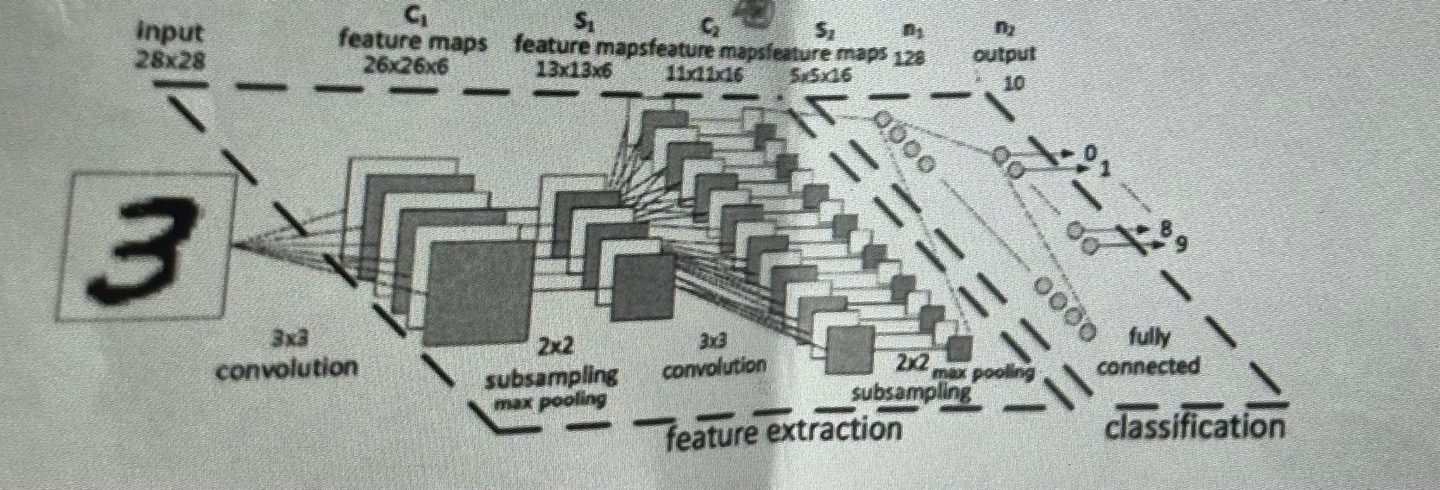

In [ ]:
'''
4.
4-1) 다음 프로그램에서 print 결과는?
4-2) weight0, weight2를 display 하는 방법을 기술하시오.

weight0 = model.layers[0].get_weights()[0]
weight2 = model.layers[2].get_weights()[0]
print(weight0)
print(weight2)
'''

'''
1) print(weight0) : 첫 번째 Conv2D층

In [ ]:
'''
5. 다음 프로그램 실행 결과를 기술하시오.
smooth = 1.

y_true_f = np.array([1, 0, 0, 1, 1, 0, 0, 1])
y_pred_f = np.array([1, 0, 0, 0, 1, 1, 0, 1])

intersection = np.sum(y_true_f * y_pred_f)
dice = (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

print(intersection, dice)
'''

'''
y_true_f 와 y_pred_f에서 1이 겹치는 부분만 1로 두는 배열을 만들고 그 배열의 합이 intersection의 값이 된다. -> intersection=3
y_true_f * y_pred_f = [1, 0, 0, 0, 1, 0, 0, 1]

dice식을 계산해보면

         2 X 3 +1      7
dice = ------------ = --- = 0.7777...
         4 + 4 +1      9

'''

3 0.7777777777777778


In [ ]:
'''
6. One-hot encoding 방식으로 segmentation 할 때
1) UNet 출력부의 변경 사항을 기술하시오
2) Loss 함수의 변경 사항을 기술하시오
3) Mask 영상을 준비할 때 변경 사항을 기술하시오
'''

'''
1) 출력 채널 수를 클래스 수로 설정하고, 활성화 함수도 Softmax로 변경해야 한다.
2) Categorical_crossentropy(교차 엔트로피)로 변경해야 한다.
3) Mask를 One-hot encoding으로 변경해야 한다.
'''

In [ ]:
'''
7. U-Net segmentation으로 자기(Custom) 영상을 준비, 학습하고 결과를 확인하는 절차를 기술하시오.
'''

'''
1. Custom 영상을 입력 영상과 마스크 영상으로 구성한다.

2. 모든 영상을 256×256 크기로 리사이즈한다.

3. 영상을 흑백(Grayscale)으로 불러오고 numpy 배열로 저장한다.

4. 영상과 마스크의 픽셀 값을 255로 나누어 0~1 사이로 정규화한다.

5. U-Net 모델을 구성하여, 입력 영상으로부터 마스크를 예측하도록 학습한다.

6. 손실 함수로 dice 계수를 사용하고, 출력층에는 sigmoid 함수를 적용한다.     -> Dice 계수를 손실함수로 사용하면 모델이 예측한 마스크와 실제 마스크의 겹치는 정도를 극대화 하여 모델을 학습 시킬수 있음

7. 학습이 완료되면 테스트 영상에 대해 마스크를 예측하고, 실제 마스크와 비교하여 결과를 시각화하고 성능을 평가한다.
'''
